In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [8]:
file_path = 'Country-data.csv'

In [2]:
print("Versao do np", np.__version__)
print("Versao do pandas", pd.__version__)
print("Versao do MatplotLib", plt.matplotlib.__version__)
print("Versao do Seaborn", sns.__version__)

Versao do np 2.3.4
Versao do pandas 2.3.3
Versao do MatplotLib 3.10.7
Versao do Seaborn 0.13.2


In [3]:
import sklearn
print("Versao do Scikit Learn", sklearn.__version__)

Versao do Scikit Learn 1.7.2


In [10]:
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "rohan0301/unsupervised-learning-on-country-data",
  file_path,
)
print("First 5 records:", df.head())

First 5 records:                country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [11]:
from sklearn.cluster import KMeans

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

               country  child_mort   exports    health   imports    income  \
0          Afghanistan    0.426485  0.049482  0.358608  0.257765  0.008047   
1              Albania    0.068160  0.139531  0.294593  0.279037  0.074933   
2              Algeria    0.120253  0.191559  0.146675  0.180149  0.098809   
3               Angola    0.566699  0.311125  0.064636  0.246266  0.042535   
4  Antigua and Barbuda    0.037488  0.227079  0.262275  0.338255  0.148652   

   inflation  life_expec  total_fer      gdpp  
0   0.126144    0.475345   0.736593  0.003073  
1   0.080399    0.871795   0.078864  0.036833  
2   0.187691    0.875740   0.274448  0.040365  
3   0.245911    0.552268   0.790221  0.031488  
4   0.052213    0.881657   0.154574  0.114242  


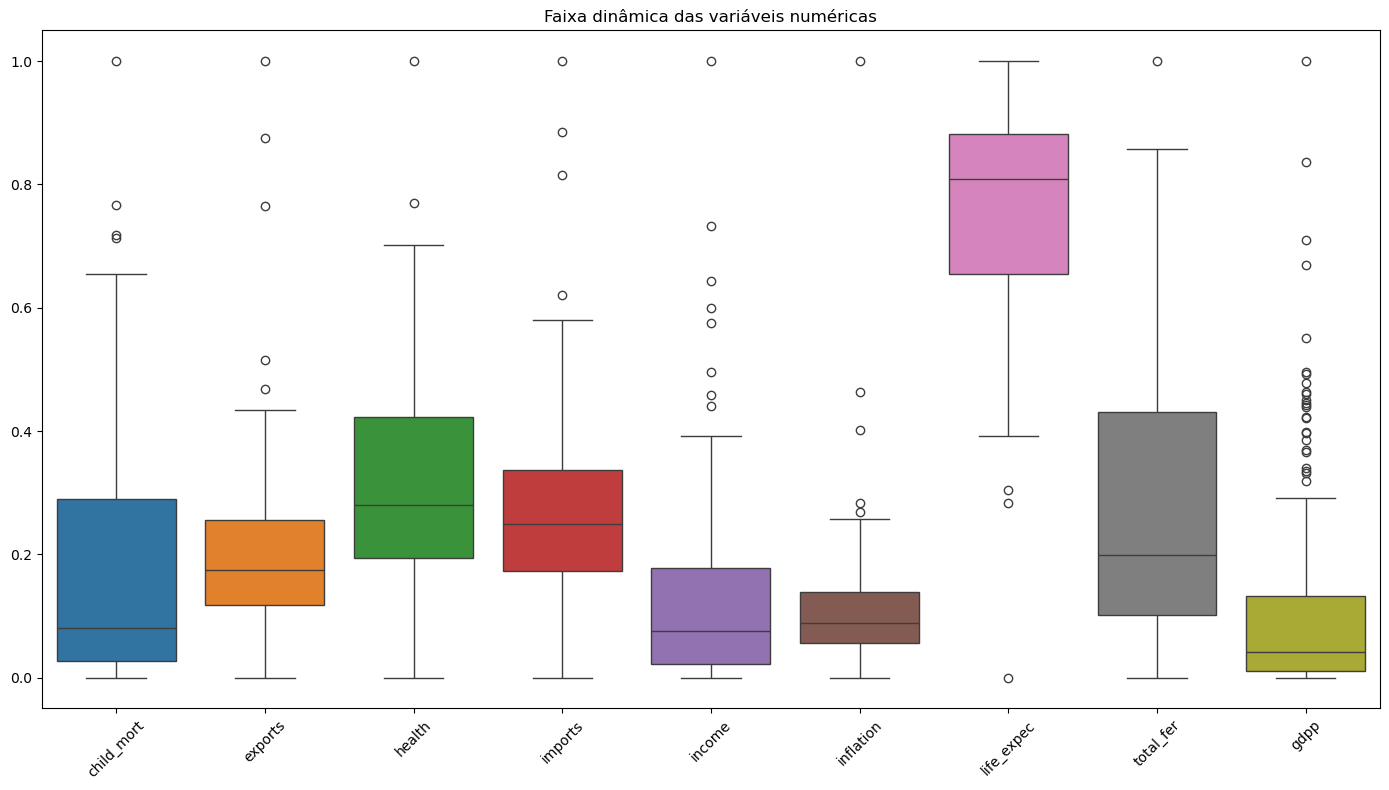

In [ ]:
numeric_cols = df.columns.drop('country')

from sklearn.preprocessing import MinMaxScaler
# Instanciar o normalizador
# Testado com MinMaxScaler e StandardScaler. Novamente MinMaxScaler apresentou melhores resultados visuais.
scaler = MinMaxScaler()

# Aplicar a normalização
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Verificar o resultado
print(df_scaled.head())

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_scaled[numeric_cols])
plt.xticks(rotation=45)
plt.title('Faixa dinâmica das variáveis numéricas')
plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


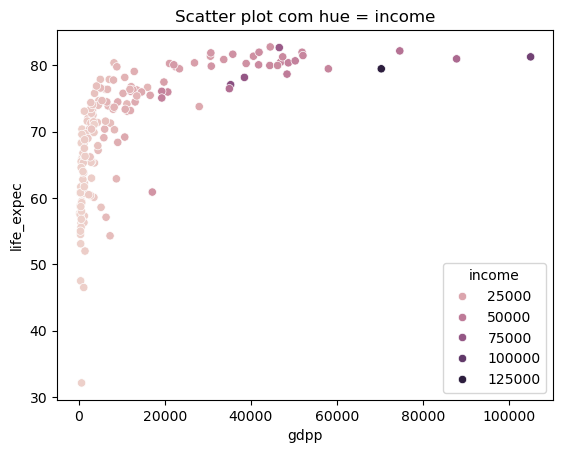

In [29]:
df.info()

sns.scatterplot(data=df, x="gdpp", y="life_expec", hue="income")
plt.title("Scatter plot com hue = income")
plt.show()

In [ ]:
f, ax = plt.subplots(figsize=(6,3))
ax.scatter()